In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split,GridSearchCV,RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report,roc_auc_score,roc_curve)
import joblib
import streamlit as sl


In [2]:
df=pd.read_csv("heart_disease_dataset.csv")

In [3]:
df.head(20)
print(df.head)

<bound method NDFrame.head of      age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0     63    1   3       145   233    1        0      150      0      2.3   
1     37    1   2       130   250    0        1      187      0      3.5   
2     41    0   1       130   204    0        0      172      0      1.4   
3     56    1   1       120   236    0        1      178      0      0.8   
4     57    0   0       120   354    0        1      163      1      0.6   
..   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
298   57    0   0       140   241    0        1      123      1      0.2   
299   45    1   3       110   264    0        1      132      0      1.2   
300   68    1   0       144   193    1        1      141      0      3.4   
301   57    1   0       130   131    0        1      115      1      1.2   
302   57    0   1       130   236    0        0      174      0      0.0   

     slope  ca  thal  target  
0        0   0     1      

In [4]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB
None


In [5]:
df.dtypes

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

In [6]:
print(df.describe())

              age         sex          cp    trestbps        chol         fbs  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000   
mean    54.366337    0.683168    0.966997  131.623762  246.264026    0.148515   
std      9.082101    0.466011    1.032052   17.538143   51.830751    0.356198   
min     29.000000    0.000000    0.000000   94.000000  126.000000    0.000000   
25%     47.500000    0.000000    0.000000  120.000000  211.000000    0.000000   
50%     55.000000    1.000000    1.000000  130.000000  240.000000    0.000000   
75%     61.000000    1.000000    2.000000  140.000000  274.500000    0.000000   
max     77.000000    1.000000    3.000000  200.000000  564.000000    1.000000   

          restecg     thalach       exang     oldpeak       slope          ca  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000   
mean     0.528053  149.646865    0.326733    1.039604    1.399340    0.729373   
std      0.525860   22.9051

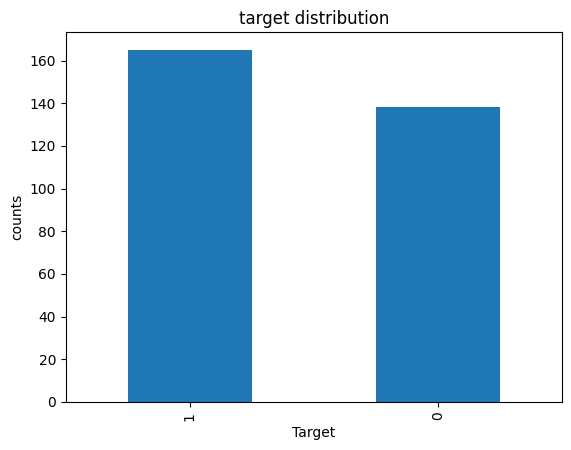

In [7]:
df['target'].value_counts().plot(kind='bar')
plt.xlabel('Target')
plt.ylabel('counts')
plt.title('target distribution')
plt.show()

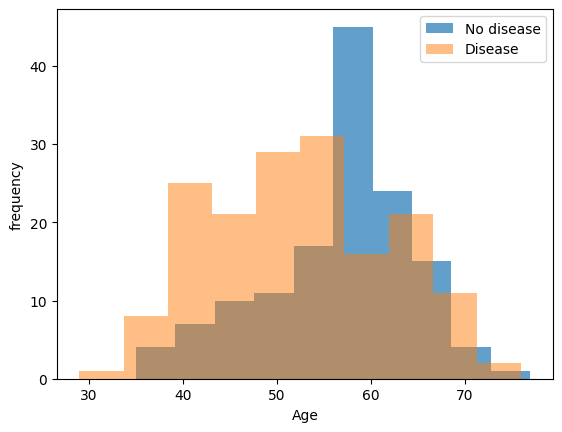

In [8]:
plt.hist(df[df['target']==0]['age'],alpha=0.7,label='No disease')
plt.hist(df[df['target']==1]['age'],alpha=0.5,label='Disease')
plt.xlabel('Age')
plt.ylabel('frequency')
plt.legend()
plt.show()

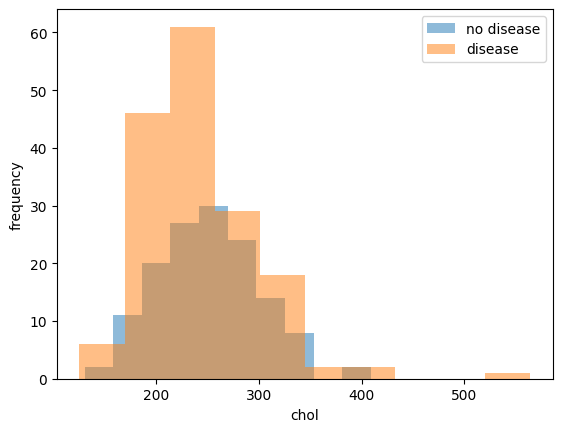

In [9]:
plt.hist(df[df['target']==0]['chol'], alpha=0.5,label='no disease')
plt.hist(df[df['target']==1]['chol'], alpha=0.5,label='disease')
plt.xlabel('chol')
plt.ylabel('frequency')
plt.legend()
plt.show()

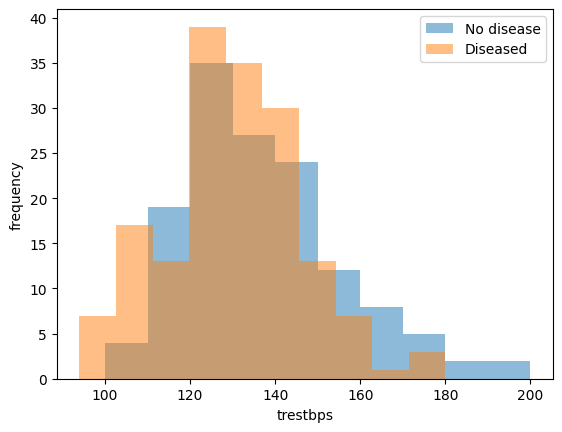

In [10]:
plt.hist(df[df['target']==0]['trestbps'],alpha=0.5,label='No disease')
plt.hist(df[df['target']==1]['trestbps'],alpha=0.5,label='Diseased')
plt.xlabel('trestbps')
plt.ylabel('frequency')
plt.legend()
plt.show()

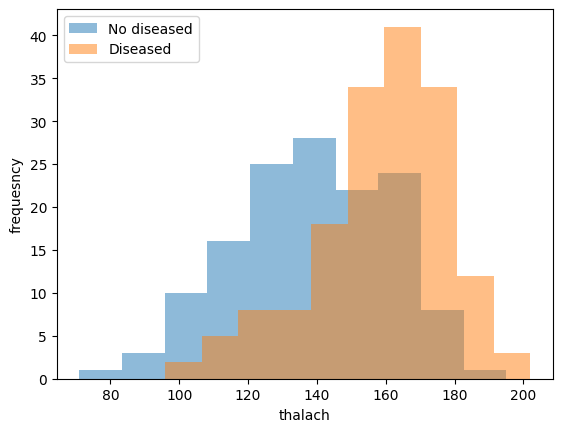

In [11]:
plt.hist(df[df['target']==0]['thalach'],alpha=0.5,label='No diseased')
plt.hist(df[df['target']==1]['thalach'],alpha=0.5,label='Diseased')
plt.xlabel('thalach')
plt.ylabel('frequesncy')
plt.legend()
plt.show()

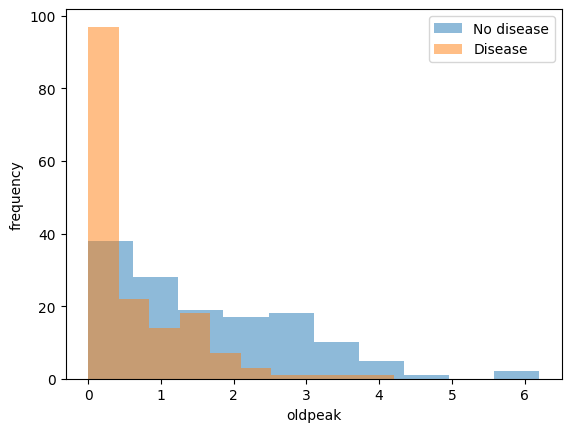

In [12]:
plt.hist(df[df['target']==0]['oldpeak'],alpha=0.5,label='No disease')
plt.hist(df[df['target']==1]['oldpeak'],alpha=0.5,label='Disease')
plt.xlabel('oldpeak')
plt.ylabel('frequency')
plt.legend()
plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_15092\2083360614.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([no,yes],labels=['no disease','disease'])


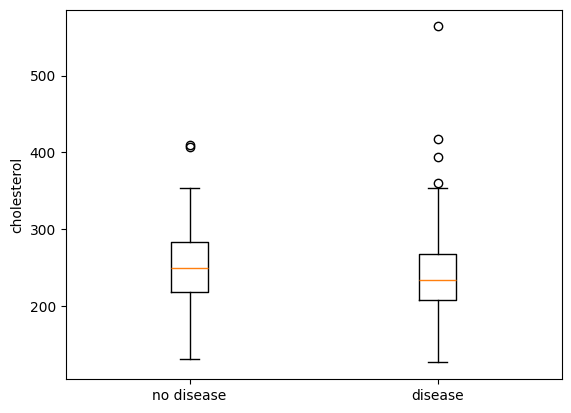

In [13]:
no=df[df['target']==0]['chol']
yes=df[df['target']==1]['chol']
plt.boxplot([no,yes],labels=['no disease','disease'])
plt.ylabel('cholesterol')
plt.show()

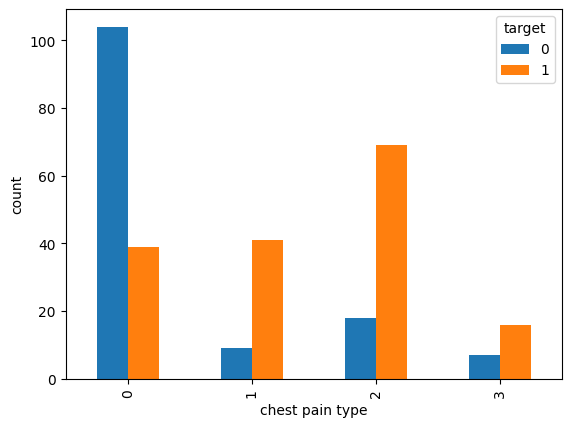

In [14]:
pd.crosstab(df['cp'],df['target']).plot(kind='bar')
plt.xlabel('chest pain type')
plt.ylabel('count')
plt.show()

In [15]:
x=df.drop('target',axis=1)
y=df['target']

In [16]:
cat_cols=['cp','restecg','thal','slope']
cont_cols=['age','trestbps','chol','thalach','oldpeak','ca']
binary_cols=['sex','fbs','exang']
print("categorical columns:",cat_cols)
print("continous columns:",cont_cols)
print("binary_cols:",binary_cols)

categorical columns: ['cp', 'restecg', 'thal', 'slope']
continous columns: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']
binary_cols: ['sex', 'fbs', 'exang']


In [17]:
x_train,x_test,y_train,y_test=train_test_split(
    x,y,test_size=0.2,stratify=y,random_state=37
)
preprocessor=ColumnTransformer(
    transformers=[
        ('num',StandardScaler(),cont_cols),
        ('cat',OneHotEncoder(drop='first'),cat_cols)
    ],
    remainder="passthrough"
)

In [18]:
x_train_processed=preprocessor.fit_transform(x_train)
x_test_processed=preprocessor.transform(x_test)
x_train_processed.shape
print(x_test_processed.shape)


(61, 19)


In [19]:
log_reg=LogisticRegression()
log_reg.fit(x_train_processed,y_train)
y_pred=log_reg.predict(x_test_processed)
y_probs=log_reg.predict_proba(x_test_processed)[:,1]
print(classification_report(y_test,y_pred))
print("ROC_AUC_SCORE:",roc_auc_score(y_test,y_pred))
plt.show()

              precision    recall  f1-score   support

           0       0.81      0.75      0.78        28
           1       0.80      0.85      0.82        33

    accuracy                           0.80        61
   macro avg       0.80      0.80      0.80        61
weighted avg       0.80      0.80      0.80        61

ROC_AUC_SCORE: 0.7992424242424243


In [20]:
ranf=RandomForestClassifier(random_state=42)
ranf.fit(x_train_processed,y_train)

y_pred_ranf=ranf.predict(x_test_processed)
y_probs_ranf=ranf.predict_proba(x_test_processed)[:,1]
print(classification_report(y_test,y_pred_ranf))
print("ROC_AUC_SCORE:",roc_auc_score(y_test,y_probs_ranf))

              precision    recall  f1-score   support

           0       0.75      0.75      0.75        28
           1       0.79      0.79      0.79        33

    accuracy                           0.77        61
   macro avg       0.77      0.77      0.77        61
weighted avg       0.77      0.77      0.77        61

ROC_AUC_SCORE: 0.8446969696969697


In [21]:
custom_threshold = 0.35
y_pred_custom = (y_probs_ranf >= custom_threshold).astype(int)
print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       0.81      0.61      0.69        28
           1       0.72      0.88      0.79        33

    accuracy                           0.75        61
   macro avg       0.77      0.74      0.74        61
weighted avg       0.76      0.75      0.75        61



In [22]:
svm=SVC(kernel='rbf',probability=True,random_state=42)
svm.fit(x_train_processed,y_train)

y_pred_svm=svm.predict(x_test_processed)
y_probs_svm=svm.predict_proba(x_test_processed)[:,1]

print(classification_report(y_test,y_pred_svm))
print("ROC_AUC_SCORE:",roc_auc_score(y_test,y_probs_svm))

              precision    recall  f1-score   support

           0       0.74      0.71      0.73        28
           1       0.76      0.79      0.78        33

    accuracy                           0.75        61
   macro avg       0.75      0.75      0.75        61
weighted avg       0.75      0.75      0.75        61

ROC_AUC_SCORE: 0.8463203463203464


c:\Users\USER\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [23]:
gb=GradientBoostingClassifier(random_state=42)
gb.fit(x_train_processed,y_train)

y_pred_gb=gb.predict(x_test_processed)
y_probs_gb=gb.predict_proba(x_test_processed)[:,1]
print(classification_report(y_test,y_pred_gb))
print("ROC_AUC_SCORE:",roc_auc_score(y_test,y_probs_gb))

              precision    recall  f1-score   support

           0       0.69      0.71      0.70        28
           1       0.75      0.73      0.74        33

    accuracy                           0.72        61
   macro avg       0.72      0.72      0.72        61
weighted avg       0.72      0.72      0.72        61

ROC_AUC_SCORE: 0.8170995670995671


In [24]:
for t in [0.3,0.35,0.4,0.45]:
    y_pred_t=(y_probs_ranf>=t).astype(int)
    print(f"threshold:{t}")
    print(classification_report(y_test,y_pred_t))

threshold:0.3
              precision    recall  f1-score   support

           0       0.84      0.57      0.68        28
           1       0.71      0.91      0.80        33

    accuracy                           0.75        61
   macro avg       0.78      0.74      0.74        61
weighted avg       0.77      0.75      0.75        61

threshold:0.35
              precision    recall  f1-score   support

           0       0.81      0.61      0.69        28
           1       0.72      0.88      0.79        33

    accuracy                           0.75        61
   macro avg       0.77      0.74      0.74        61
weighted avg       0.76      0.75      0.75        61

threshold:0.4
              precision    recall  f1-score   support

           0       0.76      0.68      0.72        28
           1       0.75      0.82      0.78        33

    accuracy                           0.75        61
   macro avg       0.76      0.75      0.75        61
weighted avg       0.75      0.

In [25]:
for t in[0.3,0.35,0.4,0.45]:
    y_pred_t=(y_probs_svm>=t).astype(int)

    print(f"threshold:{t}")
    print(classification_report(y_test,y_pred_t))
    print("-"*40)

threshold:0.3
              precision    recall  f1-score   support

           0       0.86      0.64      0.73        28
           1       0.75      0.91      0.82        33

    accuracy                           0.79        61
   macro avg       0.80      0.78      0.78        61
weighted avg       0.80      0.79      0.78        61

----------------------------------------
threshold:0.35
              precision    recall  f1-score   support

           0       0.83      0.68      0.75        28
           1       0.76      0.88      0.82        33

    accuracy                           0.79        61
   macro avg       0.79      0.78      0.78        61
weighted avg       0.79      0.79      0.78        61

----------------------------------------
threshold:0.4
              precision    recall  f1-score   support

           0       0.83      0.71      0.77        28
           1       0.78      0.88      0.83        33

    accuracy                           0.80        61
   

In [31]:
pram_grid={
    'C':[0.1,1,10,100],
    'gamma':['scale',0.01,0.1,1]
}
grid=GridSearchCV(
    SVC(kernel='rbf', probability=True,random_state=42),
    pram_grid,
    scoring='recall',
    cv=5
)
grid.fit(x_train_processed,y_train)
print("best parameters:",grid.best_params_)
print("best cross-val recall:",grid.best_score_)

best_svm=grid.best_estimator_

c:\Users\USER\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\USER\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\USER\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\USER\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\svm\_bas

best parameters: {'C': 0.1, 'gamma': 0.01}
best cross-val recall: 1.0


c:\Users\USER\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\USER\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [29]:
y_pred_best=best_svm.predict(x_test_processed)
y_probs_best=best_svm.predict_proba(x_test_processed)[0:,1]

print(classification_report(y_test,y_pred_best))
print("Roc-AOC-SCORE:",roc_auc_score(y_test,y_probs_best))

              precision    recall  f1-score   support

           0       1.00      0.25      0.40        28
           1       0.61      1.00      0.76        33

    accuracy                           0.66        61
   macro avg       0.81      0.62      0.58        61
weighted avg       0.79      0.66      0.59        61

Roc-AOC-SCORE: 0.8831168831168831


In [30]:
for t in[0.3,0.35,0.4]:
    y_pred_t=(y_probs_best>=t).astype(int)
    print(f"threshold:{t}")
    print(classification_report(y_test,y_pred_t))
    print("-"*40)

threshold:0.3
              precision    recall  f1-score   support

           0       0.74      0.71      0.73        28
           1       0.76      0.79      0.78        33

    accuracy                           0.75        61
   macro avg       0.75      0.75      0.75        61
weighted avg       0.75      0.75      0.75        61

----------------------------------------
threshold:0.35
              precision    recall  f1-score   support

           0       0.75      0.75      0.75        28
           1       0.79      0.79      0.79        33

    accuracy                           0.77        61
   macro avg       0.77      0.77      0.77        61
weighted avg       0.77      0.77      0.77        61

----------------------------------------
threshold:0.4
              precision    recall  f1-score   support

           0       0.75      0.75      0.75        28
           1       0.79      0.79      0.79        33

    accuracy                           0.77        61
   

In [32]:
grid = GridSearchCV(
    SVC(kernel='rbf', probability=True, random_state=42),
    pram_grid,
    scoring='f1',
    cv=5
)

grid.fit(x_train_processed, y_train)

print("Best parameters:", grid.best_params_)
print("Best cross-val F1:", grid.best_score_)

best_svm = grid.best_estimator_

y_pred_best = best_svm.predict(x_test_processed)
y_probs_best = best_svm.predict_proba(x_test_processed)[:, 1]

print(classification_report(y_test, y_pred_best))
print("ROC-AUC:", roc_auc_score(y_test, y_probs_best))

c:\Users\USER\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\USER\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\USER\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\USER\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\svm\_bas

Best parameters: {'C': 1, 'gamma': 0.01}
Best cross-val F1: 0.8520578174997242
              precision    recall  f1-score   support

           0       0.83      0.71      0.77        28
           1       0.78      0.88      0.83        33

    accuracy                           0.80        61
   macro avg       0.81      0.80      0.80        61
weighted avg       0.81      0.80      0.80        61

ROC-AUC: 0.8755411255411256


In [33]:
print(grid.best_params_)

{'C': 1, 'gamma': 0.01}


In [34]:
joblib.dump(best_svm, 'heart_disease_model.pkl')

['heart_disease_model.pkl']

In [35]:
joblib.dump(preprocessor, 'heart_disease_preprocessor.pkl')

['heart_disease_preprocessor.pkl']